In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv("../../../datasets/Indoor_Plant_Health_and_Growth_Factors.csv")
data.sample(5)

feature_columns = [
    'Soil_Moisture',
    'Humidity',
    'Ambient_Temperature',
    ]

target_column = 'Plant_Health_Status'

required_columns = feature_columns + [target_column]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (1000, 17)

Column names:
['Plant_ID', 'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes', 'Watering_Amount_ml', 'Watering_Frequency_days', 'Light_Intensity', 'Ambient_Temperature', 'Humidity', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Soil_Moisture', 'Soil_Type', 'Plant_Health_Status']

Data types:
Soil_Moisture          float64
Humidity               float64
Ambient_Temperature    float64
Plant_Health_Status      int64
dtype: object

Missing values per required column:
Soil_Moisture          0
Humidity               0
Ambient_Temperature    0
Plant_Health_Status    0
dtype: int64

Duplicate rows: 0


In [ ]:
dataset = data[required_columns].copy()
dataset = dataset.dropna()

print("\nShape after dropping missing values:", dataset.shape)

dataset.sample(5)


Shape after dropping missing values: (1000, 4)


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_Health_Status
387,34.1,71.4,24.3,3
334,37.9,39.9,27.6,5
402,56.0,53.8,31.6,5
106,58.6,33.9,25.2,4
343,25.1,68.0,26.1,5


In [ ]:
dataset[target_column] = dataset[target_column]

dataset = dataset.dropna(subset=[target_column])

print("\nNew target distribution:")
print(dataset[target_column].value_counts())

dataset.sample(5)


New target distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_Health_Status
631,22.4,53.9,30.2,3
448,40.6,43.2,21.9,4
738,51.6,53.7,24.1,1
202,21.6,59.8,27.3,5
33,54.9,73.6,24.9,3



Target class distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


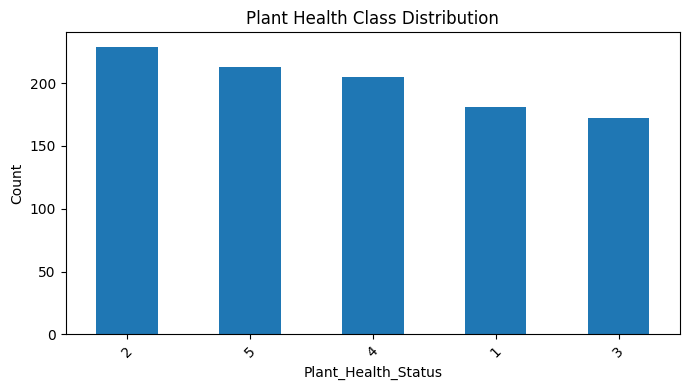

In [ ]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
x = dataset[feature_columns]
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.215


In [ ]:
print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

Train set report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       145
           2       1.00      1.00      1.00       183
           3       1.00      1.00      1.00       138
           4       1.00      1.00      1.00       164
           5       1.00      1.00      1.00       170

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

Test set report:
              precision    recall  f1-score   support

           1       0.24      0.19      0.22        36
           2       0.24      0.26      0.25        46
           3       0.16      0.12      0.14        34
           4       0.20      0.24      0.22        41
           5       0.22      0.23      0.23        43

    accuracy                           0.21       200
   macro avg       0.21      0.21      0.21       200
weighted avg       0.21      0.21      0.2

<Figure size 600x600 with 0 Axes>

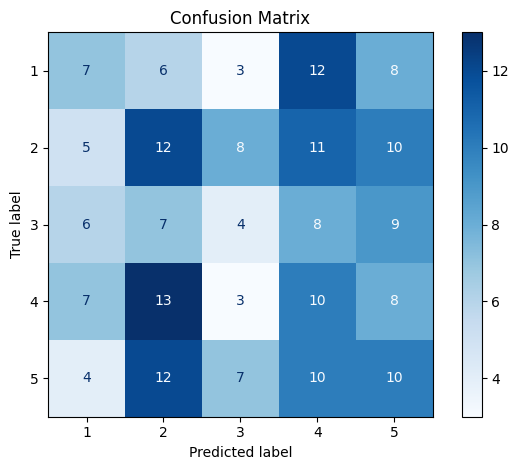

In [ ]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

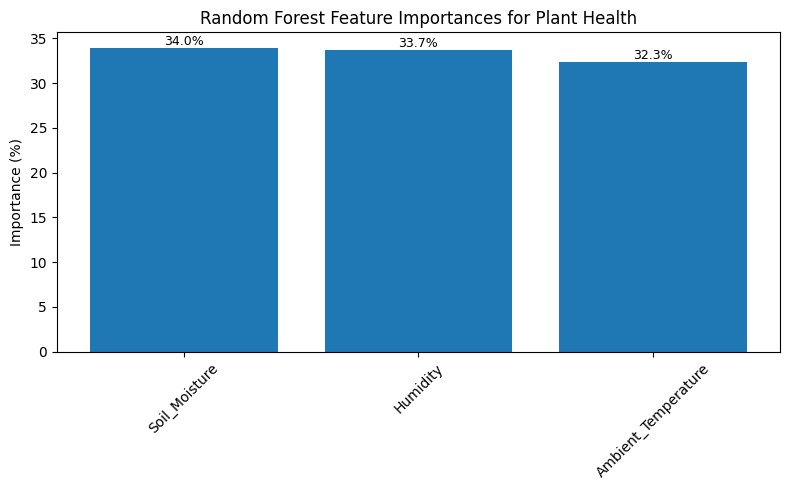

In [ ]:
importances = model.feature_importances_
feature_names = x.columns

mask = ~feature_names.str.contains("Plant_ID")

filtered_importances = importances[mask]
filtered_feature_names = feature_names[mask]

importances_pct = filtered_importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    filtered_feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
print("Dataset Validation Summary")
print("--------------------------")
print(f"Rows used: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {data[required_columns].isnull().any(axis=1).sum()}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")

Dataset Validation Summary
--------------------------
Rows used: 1000
Features used: ['Soil_Moisture', 'Humidity', 'Ambient_Temperature']
Target classes: [1, 2, 3, 4, 5]
Missing values removed: 0
Duplicate rows in original data: 0
Test accuracy: 0.2150


Soil_Moisture          0.003656
Humidity               0.031807
Ambient_Temperature    0.064063
Plant_Health_Status    1.000000
Name: Plant_Health_Status, dtype: float64


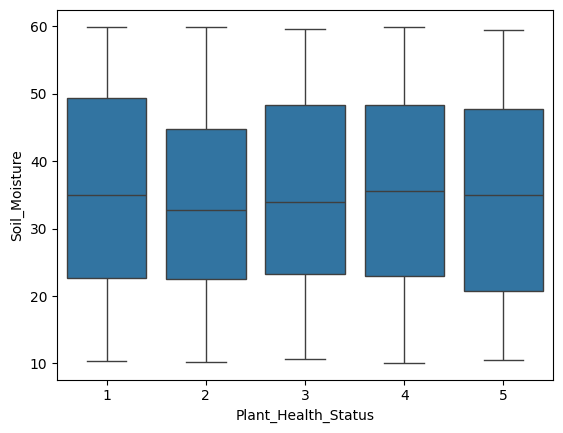

In [ ]:
dataset_numeric = dataset.copy()

print(dataset_numeric.corr(numeric_only=True)['Plant_Health_Status'])
import seaborn as sns

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()

In [ ]:
import shap

explainer = shap.Explainer(model, x_train)
shap_values = explainer(x_test)

print(shap_values.shape)

shap.plots.beeswarm(shap_values[..., 0])

shap.plots.beeswarm(shap_values[..., 1])
shap.plots.beeswarm(shap_values[..., 2])

clustering = shap.utils.hclust(X)
shap.plots.bar(shap_values[..., 0], clustering=clustering)